# LiteRT On-Device Image Classification Report

This notebook demonstrates the end-to-end flow of the LiteRT project, including model consumption, inference visualization, and performance benchmarking.

## 1. Setup & Imports

In [2]:
import sys
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# Add project root to path to import src
sys.path.append(os.path.abspath(".."))

from src import run_inference, run_comparison, load_labels

## 2. Models Check
Let's see what models we have converted.

In [3]:
!ls -lh ../models/

total 27M
-rw-rw-r-- 1 dhkim dhkim 14M  1월 17 00:47 mobilenet_v2_int8.tflite
-rw-rw-r-- 1 dhkim dhkim 14M  1월 17 00:32 mobilenet_v2.tflite


## 3. Inference Demo
Run inference on a sample image using the FP32 model.

Loading LiteRT model: ../models/mobilenet_v2.tflite
Model input shape: [  1   3 224 224]


INFO: Created TensorFlow Lite XNNPACK delegate for CPU.



Inference Time: 14.68 ms
Top 5 Results:
tiger cat: 14.3083
Egyptian cat: 14.0223
lynx: 12.4235
tabby: 12.2625
plastic bag: 9.5830


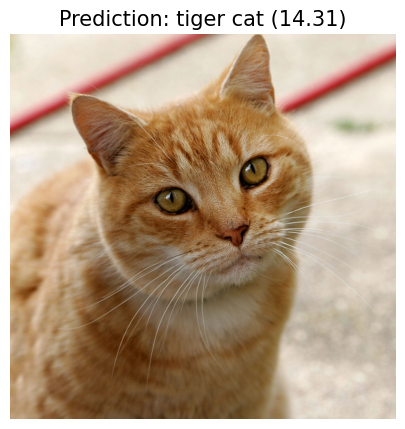

Inference Time: 14.68 ms
Top 5 Predictions:
- tiger cat: 14.3083
- Egyptian cat: 14.0223
- lynx: 12.4235
- tabby: 12.2625
- plastic bag: 9.5830


In [4]:
model_path = "../models/mobilenet_v2.tflite"
image_path = "../test_image.jpg"

# Run Inference
result = run_inference(model_path, image_path)

# Visualization
plt.figure(figsize=(10, 5))
img = Image.open(image_path)
plt.imshow(img)
plt.axis('off')
plt.title(f"Prediction: {result['top_results'][0]['label']} ({result['top_results'][0]['score']:.2f})", fontsize=15)
plt.show()

print(f"Inference Time: {result['inference_time_ms']:.2f} ms")
print("Top 5 Predictions:")
for res in result['top_results']:
    print(f"- {res['label']}: {res['score']:.4f}")

## 4. Performance Benchmark
Compare latency and memory usage between models.

In [5]:
import pandas as pd

results = run_comparison("../models")

df = pd.DataFrame(results)
display(df)

Found 2 models. Starting benchmark...

Benchmarking ../models/mobilenet_v2.tflite...
Benchmarking ../models/mobilenet_v2_int8.tflite...

COMPARISON RESULTS
+--------------------------+-------------+--------------------+------------+------------+-----------------+
| Model                    |   Size (MB) |   Avg Latency (ms) |   Min (ms) |   Max (ms) |   Peak Mem (MB) |
+==========================+=============+====================+============+============+=================+
| mobilenet_v2.tflite      |       13.43 |              12.39 |      12.27 |      12.68 |          750.58 |
+--------------------------+-------------+--------------------+------------+------------+-----------------+
| mobilenet_v2_int8.tflite |       13.43 |              12.36 |      12.24 |      12.76 |          750.66 |
+--------------------------+-------------+--------------------+------------+------------+-----------------+


,file,size_mb,avg_ms,min_ms,max_ms,std_ms,mem_peak_mb
0,mobilenet_v2.tflite,13.426849,12.388563,12.273550,12.676716,0.091303,750.582031
1,mobilenet_v2_int8.tflite,13.426849,12.355013,12.244463,12.758970,0.097060,750.660156


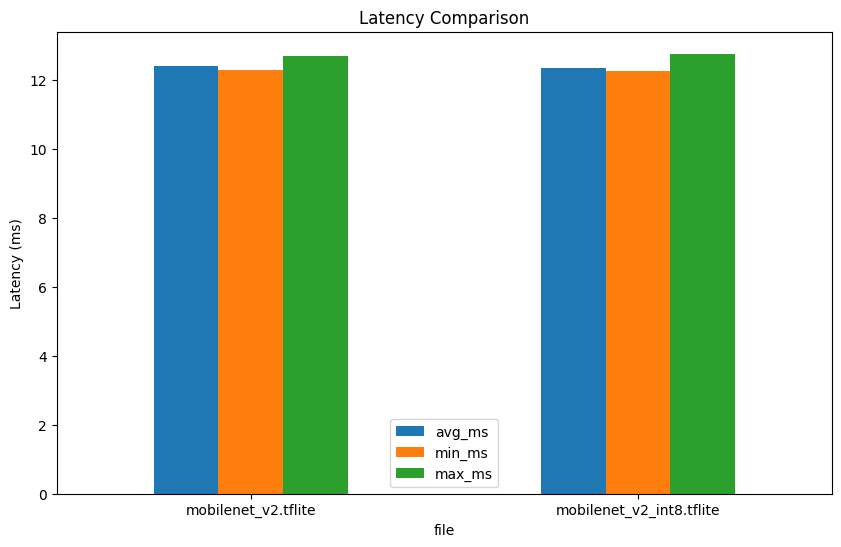

In [6]:
if results:
    df.plot(x="file", y=["avg_ms", "min_ms", "max_ms"], kind="bar", figsize=(10, 6), rot=0, title="Latency Comparison")
    plt.ylabel("Latency (ms)")
    plt.show()